# Filter Methods: Spearman's Rank Correlation

This notebook provides a practical implementation of Spearman's Correlation for feature selection, covering:
1. **Monotonicity vs. Linearity** (Why Spearman succeeds where Pearson fails on curved data)
2. **Robustness to Outliers** (How rank-based metrics handle messy data)
3. **Feature Selection Matrix** (Identifying redundancies using Spearman's heatmap)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style for better visualization
sns.set_theme(style="whitegrid")

### 1. Monotonicity vs. Linearity
Let's create a feature `X` and a target `Y` that have a perfect *monotonic* relationship, but a highly *non-linear* one (e.g., an exponential curve like $y = x^3$). We will compare how Pearson and Spearman evaluate this relationship.

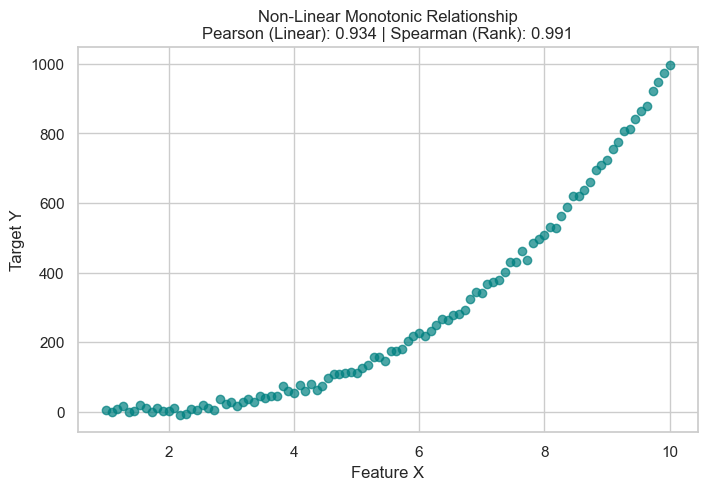

Observation: Spearman perfectly captures the underlying predictive power (score near 1.0) because the ranks consistently increase together, whereas Pearson underestimates the relationship due to the curve.


In [2]:
np.random.seed(42)

# Generate a non-linear, strictly increasing (monotonic) relationship
X_monotonic = np.linspace(1, 10, 100)
Y_monotonic = X_monotonic**3 + np.random.normal(0, 10, 100)  # y = x^3 + noise

# Calculate both correlation coefficients
pearson_r = pd.Series(X_monotonic).corr(pd.Series(Y_monotonic), method='pearson')
spearman_rho = pd.Series(X_monotonic).corr(pd.Series(Y_monotonic), method='spearman')

# Plot the relationship
plt.figure(figsize=(8, 5))
plt.scatter(X_monotonic, Y_monotonic, alpha=0.7, color='teal')
plt.title(f"Non-Linear Monotonic Relationship\nPearson (Linear): {pearson_r:.3f} | Spearman (Rank): {spearman_rho:.3f}")
plt.xlabel("Feature X")
plt.ylabel("Target Y")
plt.show()

print("Observation: Spearman perfectly captures the underlying predictive power (score near 1.0) "
      "because the ranks consistently increase together, whereas Pearson underestimates the relationship "
      "due to the curve.")

### 2. Robustness to Outliers
Now we'll generate a perfectly linear dataset, but inject a single massive outlier. We'll observe how this affects Pearson's coefficient vs. Spearman's.

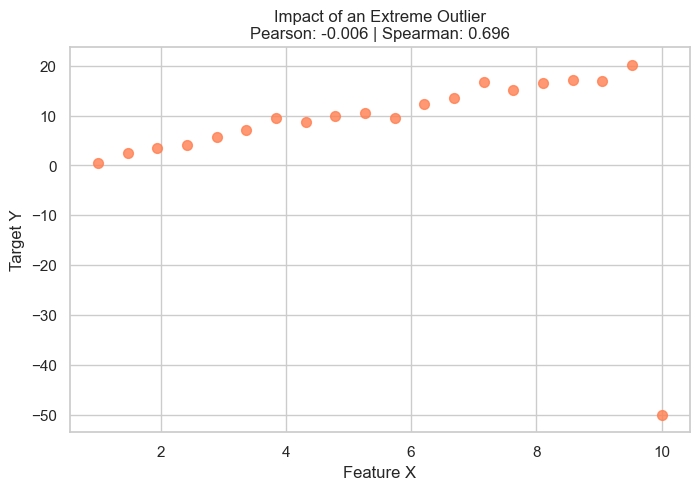

Observation: The single outlier completely destroys the Pearson correlation (drops drastically). Spearman remains highly stable because it evaluates the rank order, and one outlier only slightly shifts the ranks.


In [3]:
# Generate a linear relationship
X_outlier = np.linspace(1, 10, 20)
Y_outlier = X_outlier * 2 + np.random.normal(0, 1, 20)

# Inject an extreme outlier
X_outlier[-1] = 10
Y_outlier[-1] = -50  # This should be around 20, but we made it an extreme negative value

# Calculate both correlation coefficients
pearson_outlier = pd.Series(X_outlier).corr(pd.Series(Y_outlier), method='pearson')
spearman_outlier = pd.Series(X_outlier).corr(pd.Series(Y_outlier), method='spearman')

# Plot the relationship
plt.figure(figsize=(8, 5))
plt.scatter(X_outlier, Y_outlier, alpha=0.8, color='coral', s=50)
plt.title(f"Impact of an Extreme Outlier\nPearson: {pearson_outlier:.3f} | Spearman: {spearman_outlier:.3f}")
plt.xlabel("Feature X")
plt.ylabel("Target Y")
plt.show()

print("Observation: The single outlier completely destroys the Pearson correlation (drops drastically). "
      "Spearman remains highly stable because it evaluates the rank order, and one outlier only slightly shifts the ranks.")

### 3. Application: Feature-Feature Correlation Matrix
We will generate a synthetic telecom dataset similar to the theory notes and plot a Spearman Correlation Heatmap to identify non-linear feature redundancies.

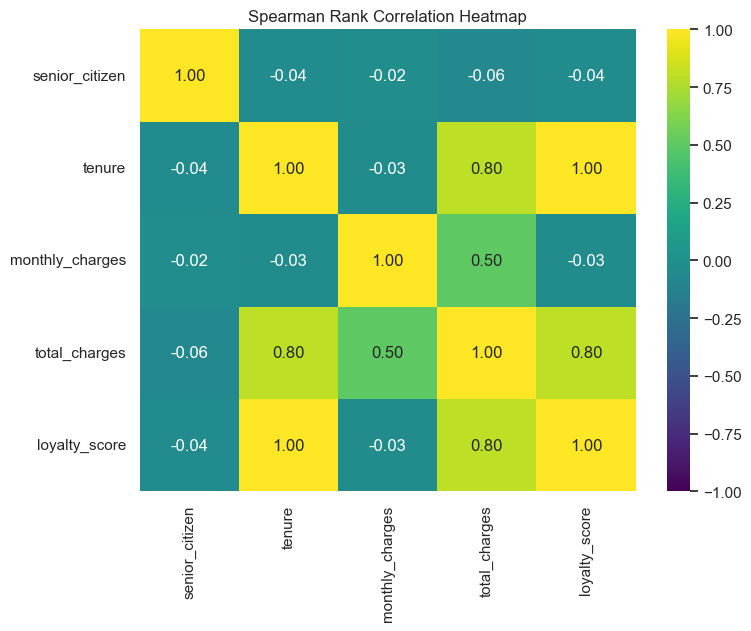

Actionable Insight: Notice the high correlation between 'tenure' and 'loyalty_score'. Because we used Spearman's, we successfully flagged this redundancy even though their relationship is exponential (non-linear). We should likely drop 'loyalty_score' before modeling.


In [4]:
# Generating synthetic data
n_samples = 1000
tenure = np.random.randint(1, 72, n_samples)
monthly_charges = np.random.uniform(20, 120, n_samples)
senior_citizen = np.random.binomial(1, 0.2, n_samples)

# Creating a non-linear but monotonic redundancy
# e.g., Loyalty score that grows exponentially with tenure
loyalty_score = (tenure ** 1.5) + np.random.normal(0, 10, n_samples)
total_charges = (tenure * monthly_charges) + np.random.normal(0, 50, n_samples)

df = pd.DataFrame({
    'senior_citizen': senior_citizen,
    'tenure': tenure,
    'monthly_charges': monthly_charges,
    'total_charges': total_charges,
    'loyalty_score': loyalty_score
})

# Compute SPEARMAN correlation matrix
spearman_matrix = df.corr(method='spearman')

# Visualize as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_matrix, annot=True, cmap='viridis', fmt=".2f", vmin=-1, vmax=1)
plt.title("Spearman Rank Correlation Heatmap")
plt.show()

print("Actionable Insight: Notice the high correlation between 'tenure' and 'loyalty_score'. "
      "Because we used Spearman's, we successfully flagged this redundancy even though their relationship is exponential (non-linear). "
      "We should likely drop 'loyalty_score' before modeling.")